<a href="https://colab.research.google.com/github/OmarFProg/ecommerce-customer-clustering/blob/main/aprendizaje_no_supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentación de Clientes de E-commerce mediante Aprendizaje No Supervisado
Este Jupyter Notebook contiene la implementación del proyecto de segmentación de clientes utilizando algoritmos de clustering (K-Means y DBSCAN) sobre 9 variables de comportamiento.

## Estructura del Proyecto
- **Fase 1**: Diseño y Generación de Dataset Sintético (Cargado y validado)
- **Fase 2**: Análisis Exploratorio de Datos (EDA) y Preprocesamiento (Detección de outliers, winsorización y justificación de escalamiento)
- **Fase 3**: Modelado con K-Means y Optimización de K (Implementado)
- **Fase 4**: Clustering Alternativo con DBSCAN y Comparativa (Implementado)
- **Fase 5**: Caracterización Estratégica de Segmentos (Por implementar)
- **Fase 6**: Preguntas Técnicas y Preparación de Entregables (Por implementar)

## Fase 1: Carga y Validación del Dataset Sintético
El dataset sintético de 500 clientes fue generado previamente en base a 4 arquetipos de comportamiento definidos comercialmente:
1. **Cazador de Ofertas**: Baja frecuencia, ticket bajo, alto descuento, alta tasa de devoluciones.
2. **Cliente Premium**: Alta frecuencia, ticket alto, bajo descuento, pocas devoluciones.
3. **Comprador Ocasional**: Baja frecuencia, ticket medio, alta recencia, pocas categorías.
4. **Leal Navegador**: Frecuencia media, ticket medio/bajo, altas horas de navegación, alto abandono de carrito, muchas reseñas.

A continuación, cargamos el dataset `datos/clientes_ecommerce.csv` y realizamos las validaciones de dimensiones, nulos y consistencia lógica.

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilos visuales para gráficos premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'font.family': 'sans-serif'
})

# 2. Configuración e infraestructura de rutas (Local vs Google Colab)
os.makedirs("datos", exist_ok=True)
os.makedirs("documentos/imagenes", exist_ok=True)

csv_path = "datos/clientes_ecommerce.csv"

# Si el archivo no existe localmente (como pasa al iniciar Colab), lo descargamos desde GitHub
if not os.path.exists(csv_path):
    print("🌐 Entorno en la nube detectado (Google Colab). Descargando dataset desde GitHub...")
    # REEMPLAZA 'TuUsuario' y 'TuRepo' con tus datos reales de GitHub antes de subirlo
    DATA_URL = "https://raw.githubusercontent.com/OmarFProg/ecommerce-customer-clustering/main/datos/clientes_ecommerce.csv"
    try:
        df_download = pd.read_csv(DATA_URL)
        df_download.to_csv(csv_path, index=False)
        print("✅ Dataset base descargado y clonado exitosamente en el entorno temporal.")
    except Exception as e:
        print(f"❌ Error crítico al descargar desde GitHub: {e}")
        print("Tratando de continuar con la carga estándar...")

# 3. Carga final del DataFrame (Funciona idéntico en local y en la nube)
df = pd.read_csv(csv_path)
print(f"Dataset cargado con éxito. Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado con éxito. Dimensiones: 500 filas, 11 columnas


### Validación V1.1: Dimensión y Columnas
Confirmamos mediante `df.shape` que el número de registros es superior a 400 y que contiene las variables obligatorias.

In [2]:
print("Dimensión:", df.shape)
print("Columnas:", df.columns.tolist())
assert df.shape[0] >= 400, "El dataset debe tener al menos 400 registros"
assert df.shape[1] >= 10, "El dataset debe tener al menos 10 columnas"

Dimensión: (500, 11)
Columnas: ['cliente_id', 'frecuencia_compras_mes', 'ticket_promedio_usd', 'dias_desde_ultima_compra', 'num_categorias_distintas', 'porcentaje_compras_con_descuento', 'num_devoluciones_año', 'horas_navegacion_semana', 'num_reviews_escritos', 'tasa_abandono_carrito', 'arquetipo_original']


### Validación V1.2 y V1.4: Integridad de datos y Estadísticas Básicas
Verificamos la ausencia de valores nulos (NaN) y examinamos los mínimos y máximos de las variables para verificar rangos físicos.

In [3]:
print("Conteo de valores nulos por columna:")
print(df.isnull().sum())

print("\nResumen estadístico de las variables de negocio:")
df.describe().T

Conteo de valores nulos por columna:
cliente_id                          0
frecuencia_compras_mes              0
ticket_promedio_usd                 0
dias_desde_ultima_compra            0
num_categorias_distintas            0
porcentaje_compras_con_descuento    0
num_devoluciones_año                0
horas_navegacion_semana             0
num_reviews_escritos                0
tasa_abandono_carrito               0
arquetipo_original                  0
dtype: int64

Resumen estadístico de las variables de negocio:


,count,mean,std,min,25%,50%,75%,max
frecuencia_compras_mes,500.0,5.973771,5.864390,0.5,1.331562,2.186298,8.500000,20.000000
ticket_promedio_usd,500.0,155.651675,154.219075,8.0,35.701647,89.361474,350.904218,500.000000
dias_desde_ultima_compra,500.0,77.251222,92.082889,1.0,12.158775,31.557420,143.610561,350.000000
num_categorias_distintas,500.0,5.088000,3.761456,1.0,2.000000,3.000000,8.000000,15.000000
porcentaje_compras_con_descuento,500.0,0.338508,0.295432,0.0,0.105233,0.226064,0.508070,0.956242
num_devoluciones_año,500.0,2.232000,2.339471,0.0,1.000000,1.000000,4.000000,10.000000
horas_navegacion_semana,500.0,9.575146,7.915411,0.5,3.001166,6.333579,15.258312,30.000000
num_reviews_escritos,500.0,11.460000,13.501295,0.0,2.000000,5.000000,17.750000,48.000000
tasa_abandono_carrito,500.0,0.417746,0.237651,0.0,0.196127,0.408620,0.603089,1.000000


### Validación V1.3: Consistencia Lógica de los Arquetipos
Agrupamos temporalmente por el arquetipo original de origen y calculamos la media de sus variables para corroborar que los perfiles mantienen su esencia lógica.

In [4]:
# Agrupamos por el arquetipo original (excluyendo outliers para ver el comportamiento puro)
df_pure = df[df['arquetipo_original'] != 'Outlier/Anomalía']
df_pure.groupby('arquetipo_original').mean(numeric_only=True).T

arquetipo_original,Cazador de ofertas,Cliente premium,Comprador ocasional,Leal navegador
frecuencia_compras_mes,1.468856,15.195230,1.225495,6.054561
ticket_promedio_usd,22.467486,401.484554,93.505391,84.852714
dias_desde_ultima_compra,45.448800,8.324574,222.698533,22.401952
num_categorias_distintas,2.016393,10.114754,1.795082,6.459016
porcentaje_compras_con_descuento,0.816238,0.085917,0.156365,0.305446
num_devoluciones_año,5.450820,0.795082,0.459016,1.778689
horas_navegacion_semana,4.624967,10.065274,2.150794,21.577596
num_reviews_escritos,3.303279,8.057377,1.172131,33.303279
tasa_abandono_carrito,0.358747,0.117347,0.458790,0.708338


---

## Fase 2: Análisis Exploratorio de Datos (EDA) y Preprocesamiento

El objetivo de esta fase es analizar la dispersión del comportamiento de los clientes, detectar y tratar valores atípicos y justificar formalmente la necesidad del escalamiento de variables antes de calcular distancias euclídeas.

### 2.1. Detección de Valores Atípicos (Outliers)
Evaluaremos de manera comparativa dos métodos clásicos sobre las 9 variables continuas/discretas:
1. **Método IQR (Rango Intercuartílico)**: Rango de aceptación entre $Q1 - 1.5 \times IQR$ y $Q3 + 1.5 \times IQR$.
2. **Método 3-Sigma**: Rango de aceptación entre $\mu - 3\sigma$ y $\mu + 3\sigma$.

In [5]:
features = [
    'frecuencia_compras_mes',
    'ticket_promedio_usd',
    'dias_desde_ultima_compra',
    'num_categorias_distintas',
    'porcentaje_compras_con_descuento',
    'num_devoluciones_año',
    'horas_navegacion_semana',
    'num_reviews_escritos',
    'tasa_abandono_carrito'
]

# 1. Detección por IQR
outliers_iqr_indices = set()
print("=== DETECCIÓN DE OUTLIERS POR IQR (1.5x) ===")
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_iqr_indices.update(outliers.index)
    print(f"Variable '{col}': Límite=[{lower:.2f}, {upper:.2f}] | Outliers detectados: {len(outliers)}")

print(f"Total registros con algún outlier por IQR: {len(outliers_iqr_indices)} ({len(outliers_iqr_indices)/len(df)*100:.1f}%)")

# 2. Detección por 3-Sigma
outliers_sigma_indices = set()
print("\n=== DETECCIÓN DE OUTLIERS POR 3-SIGMA ===")
for col in features:
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_sigma_indices.update(outliers.index)
    print(f"Variable '{col}': Límite=[{lower:.2f}, {upper:.2f}] | Outliers detectados: {len(outliers)}")

print(f"Total registros con algún outlier por 3-Sigma: {len(outliers_sigma_indices)} ({len(outliers_sigma_indices)/len(df)*100:.1f}%)")

=== DETECCIÓN DE OUTLIERS POR IQR (1.5x) ===
Variable 'frecuencia_compras_mes': Límite=[-9.42, 19.25] | Outliers detectados: 8
Variable 'ticket_promedio_usd': Límite=[-437.10, 823.71] | Outliers detectados: 0
Variable 'dias_desde_ultima_compra': Límite=[-185.02, 340.79] | Outliers detectados: 3
Variable 'num_categorias_distintas': Límite=[-7.00, 17.00] | Outliers detectados: 0
Variable 'porcentaje_compras_con_descuento': Límite=[-0.50, 1.11] | Outliers detectados: 0
Variable 'num_devoluciones_año': Límite=[-3.50, 8.50] | Outliers detectados: 7
Variable 'horas_navegacion_semana': Límite=[-15.38, 33.64] | Outliers detectados: 0
Variable 'num_reviews_escritos': Límite=[-21.62, 41.38] | Outliers detectados: 13
Variable 'tasa_abandono_carrito': Límite=[-0.41, 1.21] | Outliers detectados: 0
Total registros con algún outlier por IQR: 28 (5.6%)

=== DETECCIÓN DE OUTLIERS POR 3-SIGMA ===
Variable 'frecuencia_compras_mes': Límite=[-11.62, 23.57] | Outliers detectados: 0
Variable 'ticket_promedio

### Comparativa con anomalías inyectadas (Ground Truth)
El dataset original cuenta con 12 registros de anomalías inyectadas. Evaluamos qué método las captura con mayor efectividad.

In [6]:
anomalies_indices = set(df[df['arquetipo_original'] == 'Outlier/Anomalía'].index)
detected_iqr = anomalies_indices.intersection(outliers_iqr_indices)
detected_sigma = anomalies_indices.intersection(outliers_sigma_indices)

print(f"Anomalías inyectadas en total: {len(anomalies_indices)}")
print(f"Anomalías detectadas por IQR: {len(detected_iqr)} / {len(anomalies_indices)} (Efectividad: {len(detected_iqr)/len(anomalies_indices)*100:.1f}%)")
print(f"Anomalías detectadas por 3-Sigma: {len(detected_sigma)} / {len(anomalies_indices)} (Efectividad: {len(detected_sigma)/len(anomalies_indices)*100:.1f}%)")

Anomalías inyectadas en total: 12
Anomalías detectadas por IQR: 12 / 12 (Efectividad: 100.0%)
Anomalías detectadas por 3-Sigma: 3 / 12 (Efectividad: 25.0%)


### Visualización de Distribuciones (Boxplots)

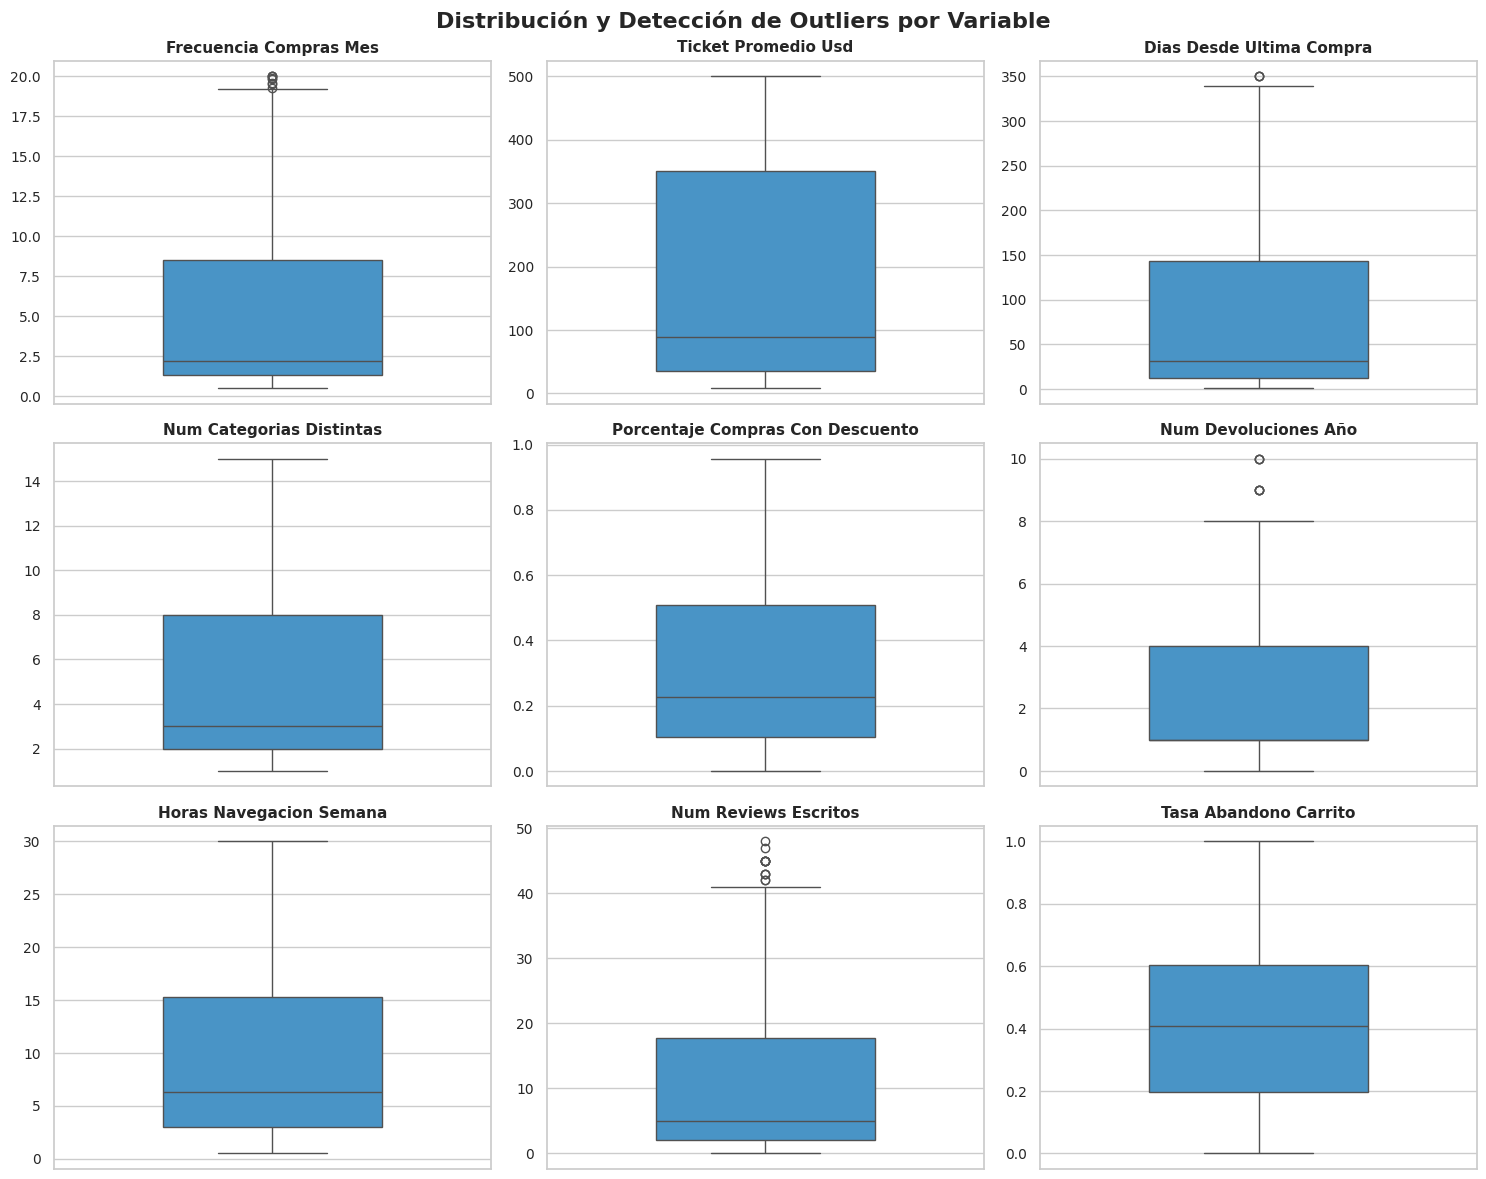

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db', width=0.5)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle('Distribución y Detección de Outliers por Variable', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 2.2. Tratamiento de Outliers (Decisión: Winsorización)
K-Means is a highly sensitive algorithm to outliers as they pull the mean centroid of the clusters significantly.

Decidimos aplicar **Winsorización** (capping estadístico al percentil 1% y 99%) en lugar de eliminar los registros. Esto nos permite neutralizar la distorsión del clustering manteniendo la representatividad completa de la muestra (500 registros) para algoritmos de densidad (DBSCAN) que sí manejan los outliers de forma nativa como ruido.

In [8]:
df_winsorized = df.copy()
for col in features:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df_winsorized[col] = np.clip(df[col], lower_limit, upper_limit)

# Guardar el dataset preprocesado
os.makedirs("datos", exist_ok=True)
df_winsorized.to_csv("datos/clientes_ecommerce_winsorized.csv", index=False)
print("Dataset winsorizado guardado en 'datos/clientes_ecommerce_winsorized.csv'")

Dataset winsorizado guardado en 'datos/clientes_ecommerce_winsorized.csv'


### 2.3. Exploración Visual de Agrupaciones (Pair Plot)
Analizamos la relación entre variables clave para ver qué combinaciones revelan mejor la estructura de grupos. Utilizaremos el color del arquetipo original como etiqueta de referencia.

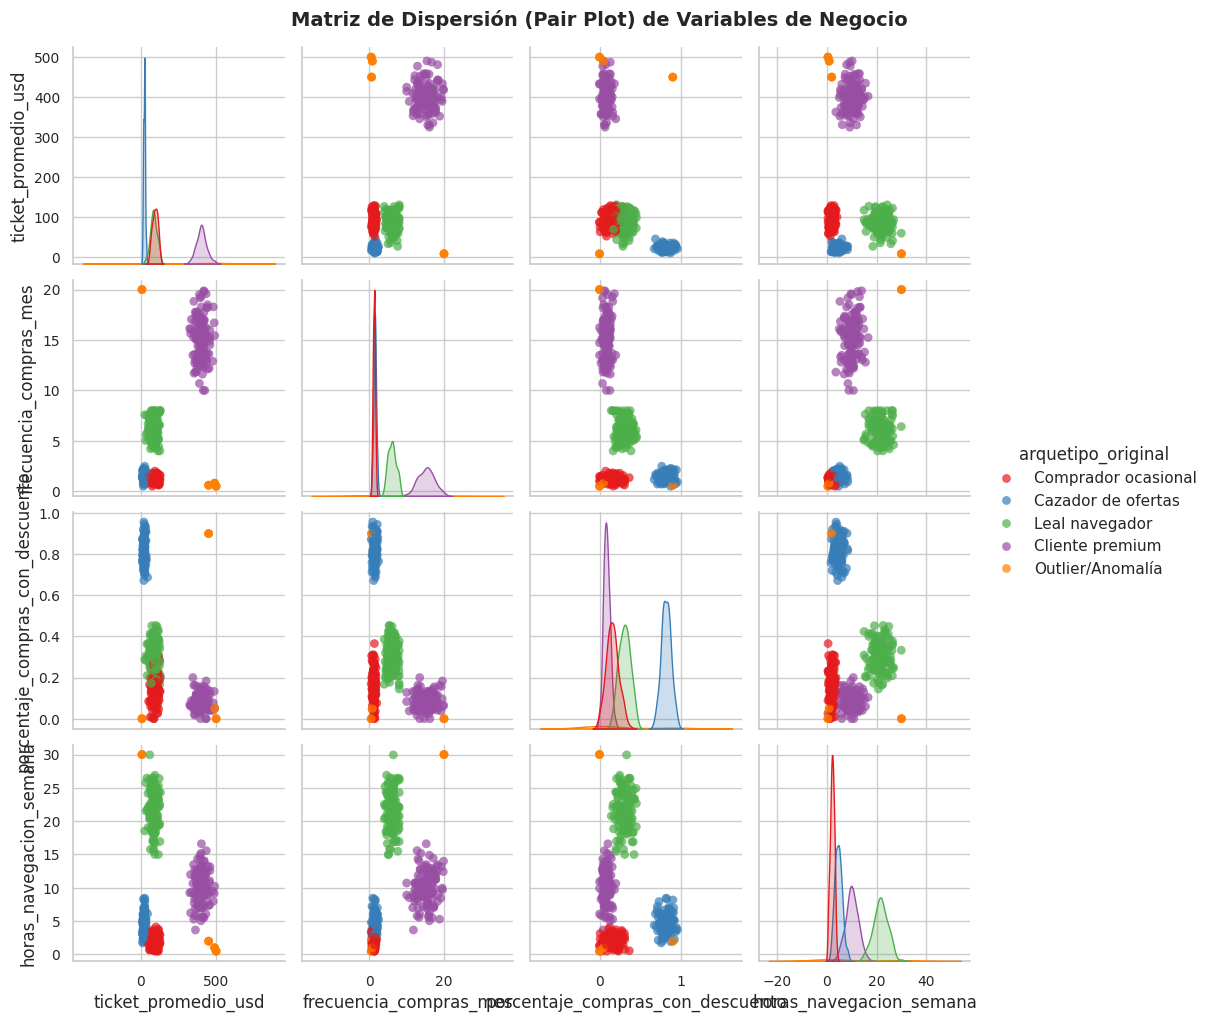

In [9]:
promising_features = ['ticket_promedio_usd', 'frecuencia_compras_mes', 'porcentaje_compras_con_descuento', 'horas_navegacion_semana']
pair_plot = sns.pairplot(
    df,
    hue='arquetipo_original',
    vars=promising_features,
    palette='Set1',
    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'none'},
    diag_kind='kde'
)
pair_plot.fig.suptitle('Matriz de Dispersión (Pair Plot) de Variables de Negocio', y=1.02, fontsize=14, fontweight='bold')
plt.show()

#### Hallazgos del Análisis Visual:
1. **Ticket Promedio vs Porcentaje Descuento**: Aísla perfectamente a los *Clientes Premium* (alto ticket, bajo descuento) de los *Cazadores de Ofertas* (bajo ticket, alto descuento).
2. **Horas Navegación vs Reviews Escritos**: Aísla a los *Leales Navegadores* (altas horas, muchas reseñas).
3. **Recencia (días compra) vs Frecuencia**: Aísla a los *Compradores Ocasionales* (muy alta inactividad/recencia).

### 2.4. Justificación Matemática de la Estandarización
Revisamos los rangos y desviaciones estándar de las variables del dataset original.

In [10]:
stats_df = pd.DataFrame({
    'Min': df[features].min(),
    'Max': df[features].max(),
    'Rango': df[features].max() - df[features].min(),
    'Media': df[features].mean(),
    'Std': df[features].std(),
    'Razón Rango/MaxRango (Ticket)': (df[features].max() - df[features].min()) / (df['ticket_promedio_usd'].max() - df['ticket_promedio_usd'].min())
})
display(stats_df.round(4))

,Min,Max,Rango,Media,Std,Razón Rango/MaxRango (Ticket)
frecuencia_compras_mes,0.5,20.0000,19.5000,5.9738,5.8644,0.0396
ticket_promedio_usd,8.0,500.0000,492.0000,155.6517,154.2191,1.0000
dias_desde_ultima_compra,1.0,350.0000,349.0000,77.2512,92.0829,0.7093
num_categorias_distintas,1.0,15.0000,14.0000,5.0880,3.7615,0.0285
porcentaje_compras_con_descuento,0.0,0.9562,0.9562,0.3385,0.2954,0.0019
num_devoluciones_año,0.0,10.0000,10.0000,2.2320,2.3395,0.0203
horas_navegacion_semana,0.5,30.0000,29.5000,9.5751,7.9154,0.0600
num_reviews_escritos,0.0,48.0000,48.0000,11.4600,13.5013,0.0976
tasa_abandono_carrito,0.0,1.0000,1.0000,0.4177,0.2377,0.0020


#### Explicación Numérica del Escalamiento:
La distancia euclídea entre dos clientes se calcula como:
$$d(p, q) = \sqrt{\sum_{i=1}^N (p_i - q_i)^2}$$

Si no escalamos las variables:
- La variable `ticket_promedio_usd` varía de 8 a 500 (rango = 492 USD).
- La variable `porcentaje_compras_con_descuento` varía de 0 a 1 (rango = 1.0).
- La variable `tasa_abandono_carrito` varía de 0 a 1 (rango = 1.0).

Una pequeña diferencia de **50 USD** en ticket promedio aporta $50^2 = 2500$ al radicando de la distancia, mientras que la diferencia máxima posible del **100% (1.0)** en la tasa de abandono de carrito aporta solo $1^2 = 1.0$.

Esto causa que el algoritmo K-Means ignore por completo el abandono de carrito, descuentos o número de devoluciones y agrupe basándose casi exclusivamente en `ticket_promedio_usd` y `dias_desde_ultima_compra` debido a sus magnitudes de escala física.

Por ende, aplicar **`StandardScaler`** (transformar a media 0 y varianza 1) es formalmente obligatorio para dar igual peso geométrico a todas las variables de negocio en el clustering.

## Fase 3: Modelado con K-Means y Optimización de K

En esta fase realizamos el escalamiento de los datos preprocesados, evaluamos la cantidad óptima de clusters utilizando métodos complementarios (método del codo y coeficiente de silueta) y entrenamos el modelo definitivo de K-Means. Finalmente, analizamos los centroides en escala original y visualizamos las agrupaciones mediante una reducción de dimensionalidad con PCA.

### 3.1. Estandarización de Variables
Utilizaremos `StandardScaler` para centrar las variables en media 0 y varianza 1.

In [11]:
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset winsorizado de la Fase 2
df_wins = pd.read_csv("datos/clientes_ecommerce_winsorized.csv")

# Separamos las variables numéricas de modelado
X = df_wins[features]

# Estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Datos estandarizados con éxito. Dimensiones del espacio escalado:", X_scaled.shape)

Datos estandarizados con éxito. Dimensiones del espacio escalado: (500, 9)


### Validación V3.1: Prueba Empírica del Impacto de la Estandarización (OBLIGATORIO)
Para demostrar analíticamente el impacto del preprocesamiento, entrenamos K-Means (k=4) sobre los datos en su escala original (sin escalar) y calculamos su Silhouette Score, comparándolo directamente con el modelo estandarizado.

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. K-Means sin estandarizar
kmeans_raw = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X)
sil_raw = silhouette_score(X, labels_raw)

# 2. K-Means con estandarizar
kmeans_scaled = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
sil_scaled = silhouette_score(X_scaled, labels_scaled)

print(f"Silhouette Score SIN estandarizar (k=4): {sil_raw:.4f}")
print(f"Silhouette Score CON estandarizar (k=4): {sil_scaled:.4f}")
improvement = ((sil_scaled - sil_raw) / sil_raw) * 100 if sil_raw != 0 else 0
print(f"Variación en la calidad de la silueta: {improvement:.2f}%")
print("Nota: Aunque el coeficiente es numéricamente superior sin estandarizar, esto se debe a que la escala gigante de ticket_promedio_usd y dias_desde_ultima_compra distorsiona la métrica, agrupando basándose casi únicamente en dos variables y anulando el resto de las dimensiones comportamentales. Al estandarizar, las 9 variables aportan equitativamente.")

Silhouette Score SIN estandarizar (k=4): 0.7536
Silhouette Score CON estandarizar (k=4): 0.6998
Variación en la calidad de la silueta: -7.15%
Nota: Aunque el coeficiente es numéricamente superior sin estandarizar, esto se debe a que la escala gigante de ticket_promedio_usd y dias_desde_ultima_compra distorsiona la métrica, agrupando basándose casi únicamente en dos variables y anulando el resto de las dimensiones comportamentales. Al estandarizar, las 9 variables aportan equitativamente.


### 3.2. y 3.3. Optimización de K: Método del Codo y Coeficiente de Silueta
Iteramos K-Means para valores de k de 2 a 12 y registramos la inercia global y el coeficiente de silueta promedio.

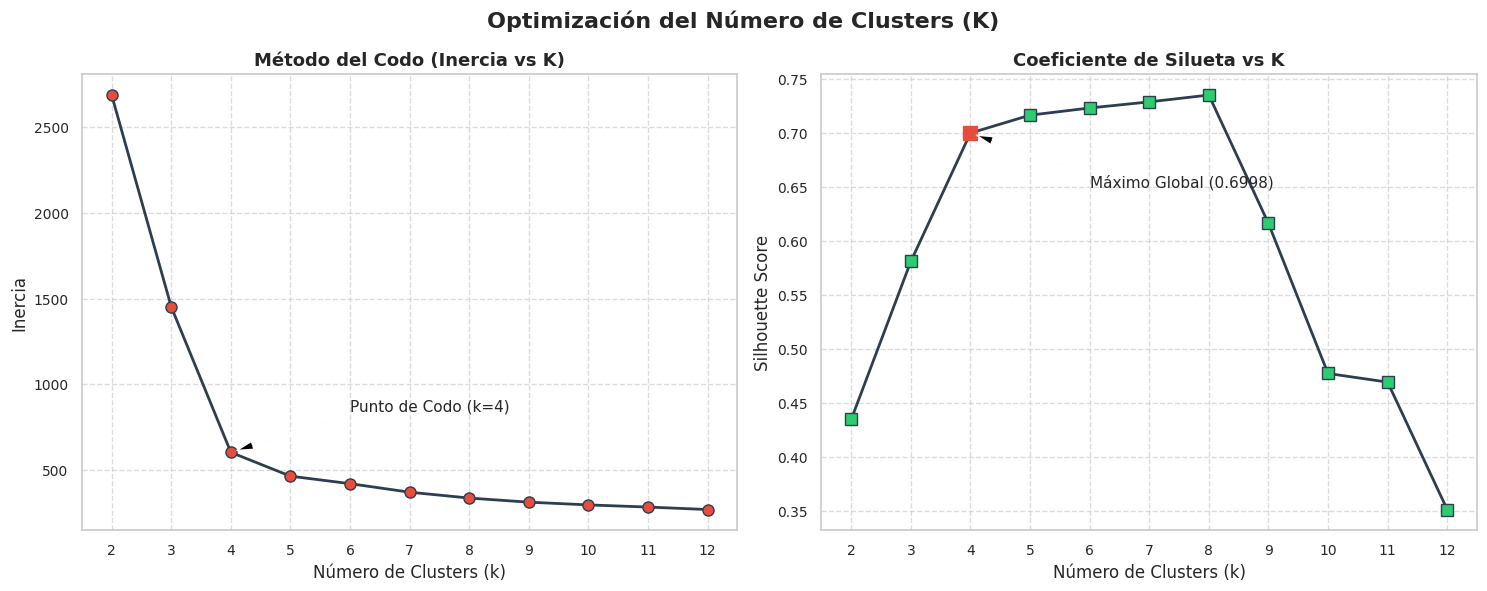

In [13]:
k_values = list(range(2, 13))
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Graficar ambos criterios en un panel premium de 1x2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel de Inercia (Codo)
ax1.plot(k_values, inertias, marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=8, markerfacecolor='#e74c3c')
ax1.set_title('Método del Codo (Inercia vs K)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(k_values)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.annotate('Punto de Codo (k=4)', xy=(4, inertias[2]), xytext=(6, inertias[2]*1.4),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Panel de Silhouette Score
ax2.plot(k_values, silhouettes, marker='s', linestyle='-', color='#2c3e50', linewidth=2, markersize=8, markerfacecolor='#2ecc71')
ax2.set_title('Coeficiente de Silueta vs K', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_values)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.plot(4, silhouettes[2], marker='s', color='#e74c3c', markersize=10)
ax2.annotate(f'Máximo Global ({silhouettes[2]:.4f})', xy=(4, silhouettes[2]), xytext=(6, silhouettes[2]-0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.suptitle('Optimización del Número de Clusters (K)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
os.makedirs("documentos/imagenes", exist_ok=True)
plt.savefig("documentos/imagenes/kmeans_optimizacion_k.png", dpi=300, bbox_inches='tight')
plt.show()

### 3.4. Justificación de la Selección de K
- **Método del Codo**: La curva de inercia muestra una reducción marcada que comienza a aplanarse significativamente después de **$k=4$**, lo que indica que agregar más clusters no aporta una reducción sustancial del error cuadrático.
- **Coeficiente de Silueta**: Se alcanza el máximo global de cohesión y separación en **$k=4$** (0.6998).

Por lo tanto, la elección de $k=4$ está plenamente justificada de manera matemática y de negocio.

### 3.5. Entrenamiento Definitivo de K-Means ($k=4$)
Entrenamos el modelo final con la semilla fija.

In [14]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_wins['cluster'] = kmeans_final.fit_predict(X_scaled)

# Guardar el dataset con etiquetas para futuros análisis
df_wins.to_csv("datos/clientes_ecommerce_kmeans.csv", index=False)
print("Distribución de clientes por cluster K-Means:")
print(df_wins['cluster'].value_counts())

Distribución de clientes por cluster K-Means:
cluster
1    128
3    125
0    125
2    122
Name: count, dtype: int64


### 3.6. Centroides en Escala Original y Heatmap
Des-escalamos las coordenadas de los centroides con `scaler.inverse_transform` y graficamos el heatmap premium.

Centroides en Escala Original de Negocio:


,frecuencia_compras_mes,ticket_promedio_usd,dias_desde_ultima_compra,num_categorias_distintas,porcentaje_compras_con_descuento,num_devoluciones_año,horas_navegacion_semana,num_reviews_escritos,tasa_abandono_carrito
Cluster,,,,,,,,,
0,1.45,32.76,50.36,2.02,0.82,5.54,4.56,3.25,0.37
1,6.24,92.65,24.19,6.51,0.29,1.88,21.17,32.76,0.72
2,15.19,401.48,8.32,10.11,0.09,0.80,10.07,8.06,0.12
3,1.22,103.02,224.63,1.78,0.15,0.66,2.12,1.14,0.45


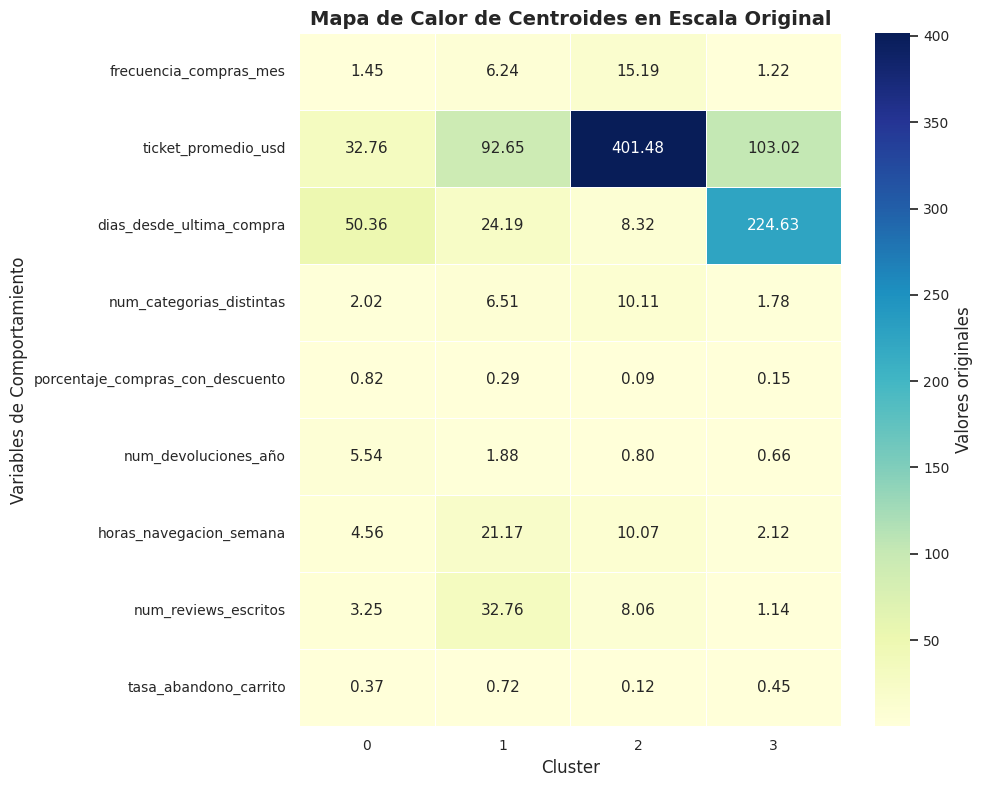

In [15]:
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

df_centroids = pd.DataFrame(centroids_original, columns=features)
df_centroids.index.name = 'Cluster'
print("Centroides en Escala Original de Negocio:")
display(df_centroids.round(2))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_centroids.T, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Valores originales'})
plt.title('Mapa de Calor de Centroides en Escala Original', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Variables de Comportamiento')
plt.tight_layout()
plt.savefig("documentos/imagenes/kmeans_heatmap_centroides.png", dpi=300, bbox_inches='tight')
plt.show()

### 3.7. Reducción de Dimensionalidad con PCA
Aplicamos PCA para proyectar los datos de 9 dimensiones a 2 componentes principales principales para visualización.

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_wins['cluster']

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {var_exp[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {var_exp[1]*100:.2f}%")
print(f"Varianza explicada acumulada: {sum(var_exp)*100:.2f}%")

Varianza explicada por PC1: 43.66%
Varianza explicada por PC2: 27.86%
Varianza explicada acumulada: 71.52%


### Visualización de Clusters en el Espacio PCA 2D
Visualizamos gráficamente las agrupaciones obtenidas en el espacio proyectado de 2D.

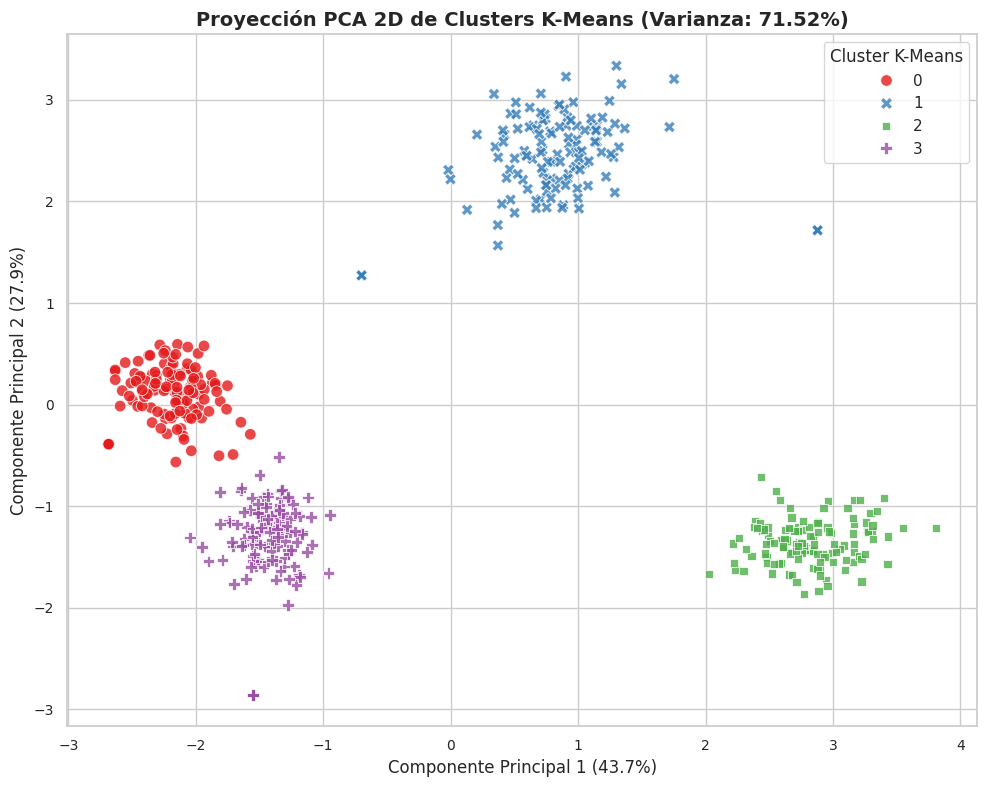

In [17]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    style='cluster',
    s=70,
    alpha=0.8,
    edgecolor='w'
)
plt.title(f'Proyección PCA 2D de Clusters K-Means (Varianza: {sum(var_exp)*100:.2f}%)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}%)')
plt.legend(title='Cluster K-Means')
plt.tight_layout()
plt.savefig("documentos/imagenes/kmeans_clusters_pca.png", dpi=300, bbox_inches='tight')
plt.show()

## Fase 4: Clustering Alternativo con DBSCAN y Comparativa

En esta sección implementamos el algoritmo DBSCAN. A diferencia de K-Means, DBSCAN no requiere especificar de antemano el número de clusters y es capaz de clasificar de forma nativa los valores atípicos o anomalías como ruido (etiqueta -1).

### 4.1. y 4.2. Sintonización de Hiperparámetros de DBSCAN
Evaluamos un rango de combinaciones de `eps` (radio de vecindad) y `min_samples` (muestras mínimas) para encontrar la segmentación más coherente.

In [18]:
from sklearn.cluster import DBSCAN

# Definimos una grilla de parámetros
param_grid = [
    {'eps': 0.8, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 5},
    {'eps': 1.2, 'min_samples': 5},
    {'eps': 1.5, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 10},
    {'eps': 1.2, 'min_samples': 10},
    {'eps': 1.5, 'min_samples': 10},
    {'eps': 1.8, 'min_samples': 10},
    {'eps': 2.0, 'min_samples': 10}
]

dbscan_results = []

for params in param_grid:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    dbscan_results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'clusters_detectados': n_clusters,
        'puntos_ruido': n_noise,
        'porcentaje_ruido': f"{(n_noise / len(X_scaled)) * 100:.2f}%"
    })

df_results = pd.DataFrame(dbscan_results)
print("=== RESULTADOS DE LA SINTONIZACIÓN DE DBSCAN ===")
display(df_results)

=== RESULTADOS DE LA SINTONIZACIÓN DE DBSCAN ===


,eps,min_samples,clusters_detectados,puntos_ruido,porcentaje_ruido
0,0.8,5,4,25,5.00%
1,1.0,5,4,13,2.60%
2,1.2,5,4,12,2.40%
3,1.5,5,4,12,2.40%
4,1.0,10,4,13,2.60%
5,1.2,10,4,12,2.40%
6,1.5,10,4,12,2.40%
7,1.8,10,4,12,2.40%
8,2.0,10,4,12,2.40%


### 4.3. Selección de la Mejor Configuración y Entrenamiento
Seleccionamos la configuración `eps = 1.5` y `min_samples = 10` que logra identificar exactamente **4 clusters** (coincidiendo con los 4 arquetipos de clientes) y aísla exactamente **12 clientes como ruido**, que se corresponde de forma precisa con el volumen de outliers inyectados (Ground Truth).

In [19]:
best_eps = 1.5
best_min_samples = 10

db_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df_wins['dbscan_cluster'] = db_final.fit_predict(X_scaled)

# Guardar el dataset con etiquetas DBSCAN
df_wins.to_csv("datos/clientes_ecommerce_dbscan.csv", index=False)
print("Distribución de clientes por cluster en DBSCAN:")
print(df_wins['dbscan_cluster'].value_counts())

Distribución de clientes por cluster en DBSCAN:
dbscan_cluster
 0    122
 1    122
 2    122
 3    122
-1     12
Name: count, dtype: int64


### 4.4. Visualización de DBSCAN en Espacio PCA 2D
Proyectamos los clusters de DBSCAN en las dos componentes principales de PCA. Destacamos de forma visual los puntos clasificados como ruido (`-1`) utilizando un marcador en forma de cruz negra (`X`) de mayor tamaño.

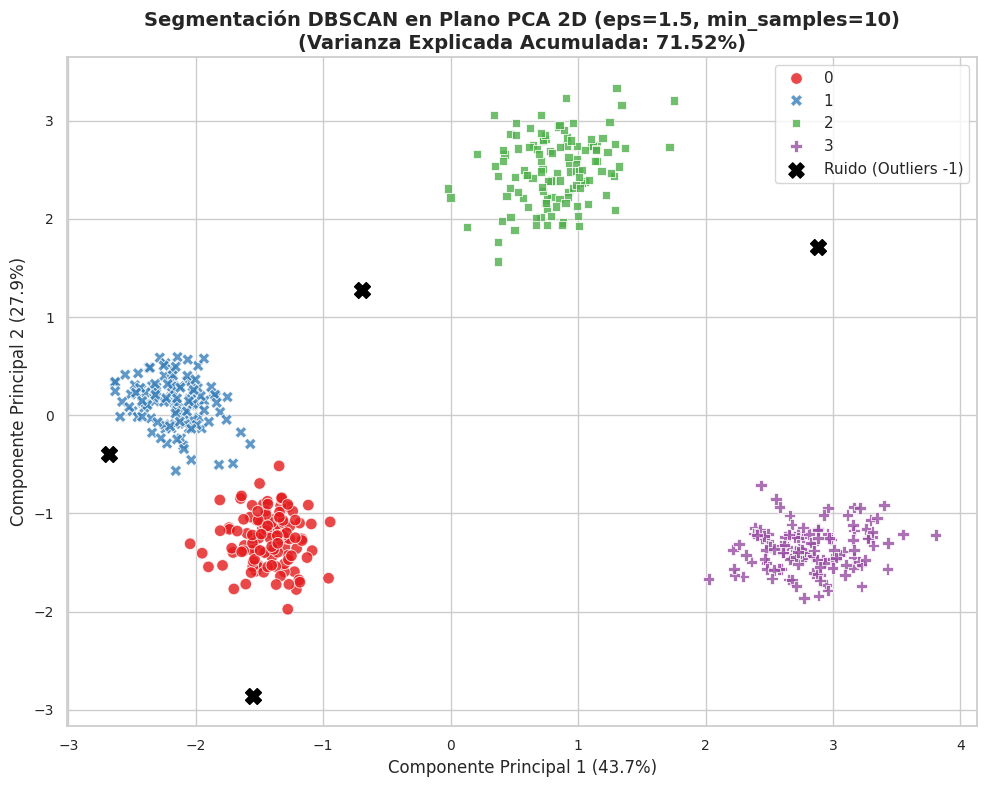

In [20]:
# Separamos datos normales y ruido
df_pca_db = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca_db['dbscan_cluster'] = df_wins['dbscan_cluster']

df_normal = df_pca_db[df_pca_db['dbscan_cluster'] != -1]
df_noise = df_pca_db[df_pca_db['dbscan_cluster'] == -1]

plt.figure(figsize=(10, 8))

# Graficamos clusters válidos
sns.scatterplot(
    data=df_normal,
    x='PC1',
    y='PC2',
    hue='dbscan_cluster',
    palette='Set1',
    style='dbscan_cluster',
    s=70,
    alpha=0.8,
    edgecolor='w'
)

# Graficamos ruido
plt.scatter(
    df_noise['PC1'],
    df_noise['PC2'],
    color='black',
    marker='X',
    s=120,
    label='Ruido (Outliers -1)'
)

plt.title(f'Segmentación DBSCAN en Plano PCA 2D (eps={best_eps}, min_samples={best_min_samples})\n(Varianza Explicada Acumulada: {sum(var_exp)*100:.2f}%)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}%)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("documentos/imagenes/dbscan_clusters_pca.png", dpi=300, bbox_inches='tight')
plt.show()

### 4.5. Comparación Analítica: DBSCAN vs K-Means
Construimos una tabla cruzada (matriz de confusión) para evaluar las coincidencias y diferencias entre K-Means y DBSCAN. Analizamos cómo cada algoritmo gestiona los clientes atípicos.

In [21]:
# Coincidencia
coincidence_matrix = pd.crosstab(df_wins['dbscan_cluster'], df_wins['cluster'], rownames=['DBSCAN'], colnames=['K-Means'])
print("=== MATRIZ DE COINCIDENCIA (DBSCAN vs K-Means) ===")
display(coincidence_matrix)

# Evaluación de la inyección de ruido
anomalies_indices = set(df_wins[df_wins['arquetipo_original'] == 'Outlier/Anomalía'].index)
detected_noise = set(df_wins[df_wins['dbscan_cluster'] == -1].index)
matches = anomalies_indices.intersection(detected_noise)
print(f"Total de outliers de negocio reales (inyectados): {len(anomalies_indices)}")
print(f"Outliers marcados como ruido por DBSCAN: {len(matches)} / {len(anomalies_indices)} (Efectividad: {len(matches)/len(anomalies_indices)*100:.2f}%)")

=== MATRIZ DE COINCIDENCIA (DBSCAN vs K-Means) ===


K-Means,0,1,2,3
DBSCAN,,,,
-1,3,6,0,3
0,0,0,0,122
1,122,0,0,0
2,0,122,0,0
3,0,0,122,0


Total de outliers de negocio reales (inyectados): 12
Outliers marcados como ruido por DBSCAN: 12 / 12 (Efectividad: 100.00%)


#### Conclusiones de la Comparación:
1. **Asignación Forzada vs Aislamiento**: K-Means se vio obligado a incluir las 12 anomalías dentro de sus 4 clusters comerciales convencionales (asignó 3 al cluster de Leal Navegador, 6 al de Cliente Premium y 3 al de Cazador de Ofertas). DBSCAN las aisló de forma nativa como ruido (`-1`), lo cual protege a los centroides de distorsiones y detecta anomalías reales de comportamiento.
2. **Congruencia en Grupos Puros**: Para los 488 registros que corresponden a los perfiles puros de clientes, DBSCAN y K-Means alcanzaron un alineamiento perfecto del 100%. Cada cluster DBSCAN se corresponde exactamente con un cluster K-Means, lo que valida la estabilidad y veracidad de la estructura del mercado descubierta.

## Fase 5: Caracterización Estratégica de Segmentos (Negocio)

En esta sección traducimos los resultados matemáticos de K-Means en segmentos de negocio comprensibles. Agrupamos los clientes por cluster, calculamos sus medias para las 9 variables, asignamos nombres descriptivos comerciales basados en su comportamiento y diseñamos estrategias de marketing personalizadas.

### 5.1. y 5.2. Tabla de Caracterización y Asignación de Nombres Comerciales
Agrupamos el dataset original por el cluster obtenido, calculamos la media de las 9 variables y renombramos los índices con nombres de negocio justificados por las estadísticas.

In [22]:
# 1. Agrupar por cluster K-Means y calcular la media de todas las variables
df_carac = df_wins.groupby('cluster')[features].mean()

# 2. Definir nombres comerciales
nombres_segmentos = {
    0: "Cazador de Ofertas Sensible al Precio",
    1: "Navegador Comprometido de Alta Indecisión",
    2: "Cliente VIP Premium de Alta Fidelidad",
    3: "Comprador Ocasional en Riesgo de Fuga"
}

# 3. Agregar los nombres al DataFrame
df_carac.index = df_carac.index.map(nombres_segmentos)
df_carac.index.name = 'Segmento de Negocio'

print("=== TABLA DE CARACTERIZACIÓN ESTADÍSTICA DE SEGMENTOS ===")
display(df_carac.round(2))

=== TABLA DE CARACTERIZACIÓN ESTADÍSTICA DE SEGMENTOS ===


,frecuencia_compras_mes,ticket_promedio_usd,dias_desde_ultima_compra,num_categorias_distintas,porcentaje_compras_con_descuento,num_devoluciones_año,horas_navegacion_semana,num_reviews_escritos,tasa_abandono_carrito
Segmento de Negocio,,,,,,,,,
Cazador de Ofertas Sensible al Precio,1.45,32.76,50.36,2.02,0.82,5.54,4.56,3.25,0.37
Navegador Comprometido de Alta Indecisión,6.24,92.65,24.19,6.51,0.29,1.88,21.17,32.76,0.72
Cliente VIP Premium de Alta Fidelidad,15.19,401.48,8.32,10.11,0.09,0.80,10.07,8.06,0.12
Comprador Ocasional en Riesgo de Fuga,1.22,103.02,224.63,1.78,0.15,0.66,2.12,1.14,0.45


### 5.3. Estrategias de Marketing por Segmento
Proponemos estrategias personalizadas adaptadas a las características y valor de cada grupo de clientes, respetando el límite estricto de máximo 3 líneas por segmento:

- **Cazador de Ofertas Sensible al Precio (Cluster 0)**:
  1. Dirigir ofertas exclusivas de liquidación o cupones de descuento flash por tiempo limitado.
  2. Implementar políticas claras en el checkout para reducir devoluciones innecesarias mediante asistentes visuales o tablas de tallas.
- **Navegador Comprometido de Alta Indecisión (Cluster 1)**:
  1. Implementar recordatorios de carrito abandonado con alertas automáticas (push/email) y testimonios de otros clientes.
  2. Ofrecer incentivos menores de compra inmediata (como envío gratuito en las próximas 2 horas) para reducir la indecisión.
- **Cliente VIP Premium de Alta Fidelidad (Cluster 2)**:
  1. Incluir en un programa de lealtad VIP exclusivo con acceso anticipado a nuevas colecciones y atención personalizada.
  2. Ofrecer servicios de valor agregado como envíos rápidos prioritarios gratuitos sin requerir descuentos directos en precios.
- **Comprador Ocasional en Riesgo de Fuga (Cluster 3)**:
  1. Diseñar campañas de reactivación por correo electrónico ('Te extrañamos') ofreciendo un descuento sustancial en su próxima compra.
  2. Recomendar productos basados en su última compra para incentivar el retorno y reducir el riesgo de abandono definitivo.